<a href="https://colab.research.google.com/github/tinemyumi/saude-mental-datasus/blob/main/notebooks/5.visao_geral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Visão geral, estrutura do dataset e análise temporal das internações**

### **Objetivo**
Descrever a estrutura e a qualidade do dataset de internações em saúde mental (SIH/SUS - SP, 2015–2025) e analisar a série temporal das internações

**Autor:** Larissa Tinem


## **1. Setup**

In [ ]:
# Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Paleta e estilo
COLOR1 = '#1B4F72'   # azul escuro
COLOR2 = '#48C9B0'   # verde-azulado
COLOR3 = '#5499C7'   # azul médio
COLORS = [COLOR1, COLOR2, COLOR3]
PALETTE_PERIODO = {
    'Pre-Pandemia' : COLOR1,
    'Pandemia'     : COLOR2,
    'Pos-Pandemia' : COLOR3,
}

plt.rcParams['figure.dpi']      = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
sns.set_style('whitegrid')

# Ordem dos períodos
ORDEM_PERIODOS = ['Pre-Pandemia', 'Pandemia', 'Pos-Pandemia']

## **2. Carregamento dos Dados**

In [ ]:
# Carregar os arquivos
df = pd.read_parquet('/content/drive/MyDrive/Dados/dados_tratados/df_sihsus.parquet')
df_pop = pd.read_csv('/content/drive/MyDrive/Dados/dados_tratados/df_populacao_sp')

## **3. Qualidade dos Dados**

### **3.1. Valores Nulos**

In [ ]:
df.isna().sum()

,0
N_AIH,0
cod_municipio,0
IDENT,0
ANO_CMPT,0
MES_CMPT,0
NASC,0
IDADE,0
SEXO,0
RACA_COR,0
ESPEC,0


### **3.2. Valores duplicados**



In [ ]:
print('Valores duplicados de df: ', df.duplicated().sum())
print('Valores duplicados de df_pop: ', df_pop.duplicated().sum())

Valores duplicados de df:  0
Valores duplicados de df_pop:  0


### **3.3. Limitações**
Queda esperada ao longo dos anos indica melhora no preenchimento, o que impacta a análise de raça: documentar na seção de limitações do artigo.

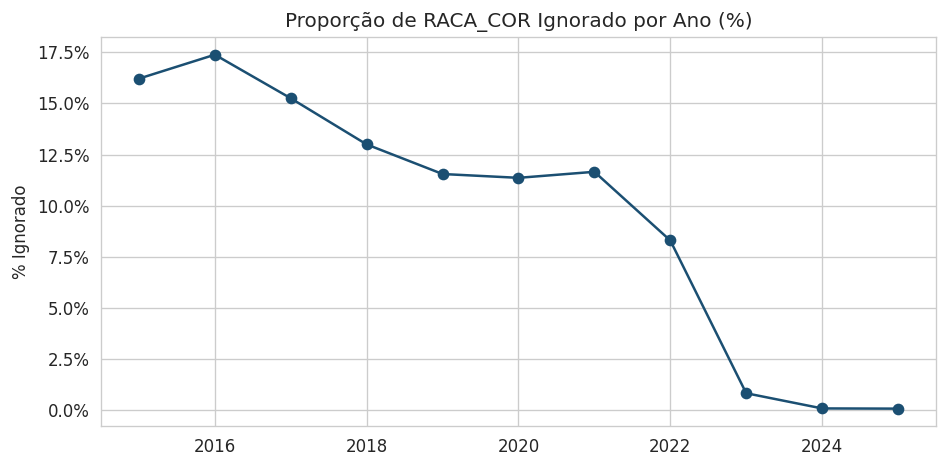

In [ ]:
# Evolução anual do preenchimento de RACA_COR
raca_ignorado = (
    df.assign(ignorado=df['RACA_COR'] == '99')
    .groupby('ANO_CMPT')['ignorado']
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(8, 4))
raca_ignorado.plot(ax=ax, marker='o', color=COLOR1)
ax.set_title('Proporção de RACA_COR Ignorado por Ano (%)')
ax.set_ylabel('% Ignorado')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.show()


### **3.4 Consistência**

In [ ]:
# Verifica valores inesperados nas variáveis categóricas principais
checks = {
    'SEXO'   : ['1', '3'],
    'CAR_INT': ['01', '02'],
    'MORTE'  : ['0', '1'],
    'COMPLEX': ['01', '02', '03'],
}

for col, valores_esperados in checks.items():
    valores_encontrados = df[col].unique().tolist()
    inesperados = [v for v in valores_encontrados if v not in valores_esperados]
    status = '✅' if not inesperados else f'⚠️  {inesperados}'
    print(f'{col:10s} | esperado: {valores_esperados} | {status}')

SEXO       | esperado: ['1', '3'] | ✅
CAR_INT    | esperado: ['01', '02'] | ✅
MORTE      | esperado: ['0', '1'] | ✅
COMPLEX    | esperado: ['01', '02', '03'] | ✅


In [ ]:
# Verifica consistência de datas e idade
print(f'Período coberto    : {df["ANO_CMPT"].min()} – {df["ANO_CMPT"].max()}')
print(f'Idades negativas   : {(df["IDADE"] < 0).sum()}')
print(f'Idades > 120       : {(df["IDADE"] > 120).sum()}')
print(f'DT_SAIDA < DT_INTER: {(df["DT_SAIDA"] < df["DT_INTER"]).sum()}')
print(f'DIAS_PERM < 0      : {(df["DIAS_PERM"] < 0).sum()}')

Período coberto    : 2015 – 2025
Idades negativas   : 0
Idades > 120       : 0
DT_SAIDA < DT_INTER: 0
DIAS_PERM < 0      : 0


## **4. Série Temporal**


Taxa média mensal por 100 mil habitantes:
        periodo  taxa_100k
0  Pre-Pandemia       20.2
1      Pandemia       14.1
2  Pos-Pandemia       16.8


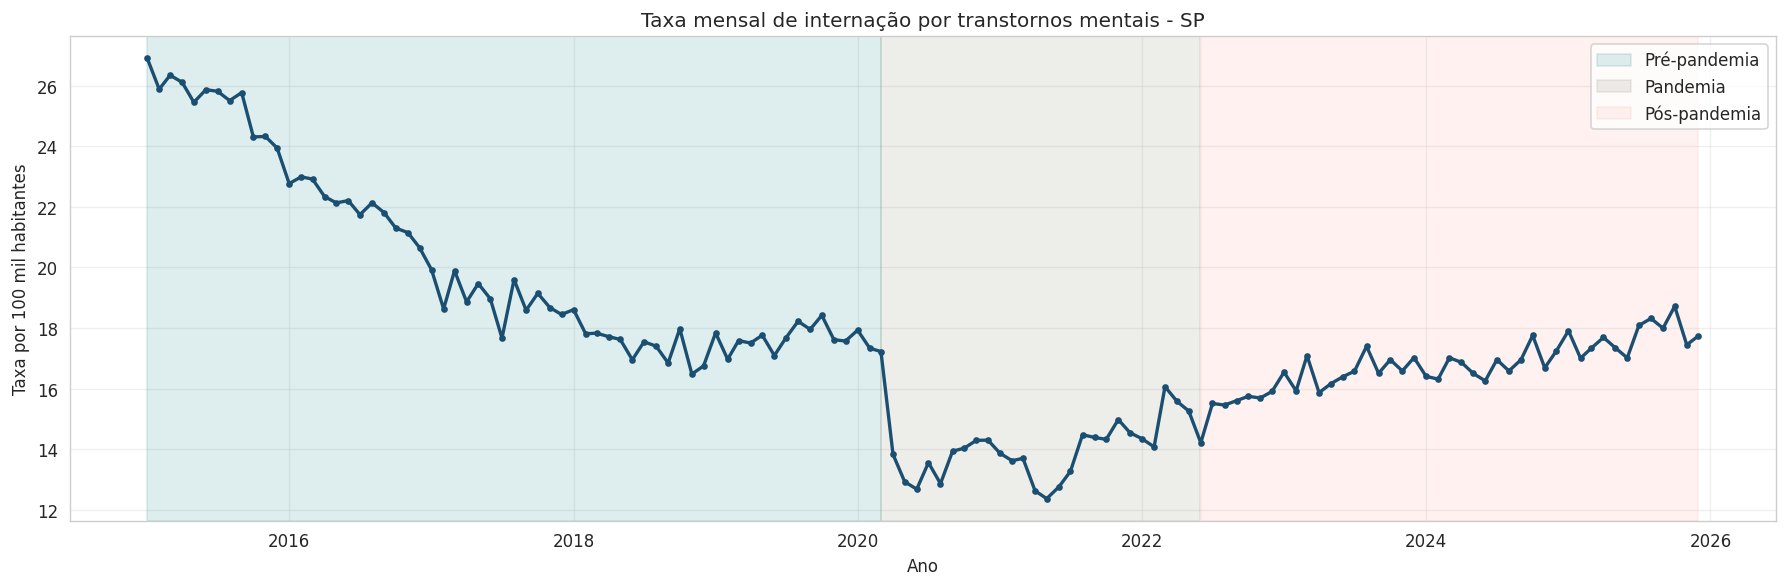

In [ ]:
# BASE PRINCIPAL

df_tratado = df.copy()

# data de referência mensal
df_tratado['data_ref'] = pd.to_datetime(
    df_tratado['ANO_CMPT'].astype(str) + '-' +
    df_tratado['MES_CMPT'].astype(str).str.zfill(2) + '-01'
)

# DEFINIÇÃO DOS PERÍODOS

inicio_pandemia = pd.Timestamp('2020-03-01')
inicio_pos = pd.Timestamp('2022-06-01')

df_tratado['periodo'] = np.where(
    df_tratado['data_ref'] < inicio_pandemia,
    'Pre-Pandemia',
    np.where(
        df_tratado['data_ref'] < inicio_pos,
        'Pandemia',
        'Pos-Pandemia'
    )
)

df_tratado['periodo'] = pd.Categorical(
    df_tratado['periodo'],
    categories=['Pre-Pandemia', 'Pandemia', 'Pos-Pandemia'],
    ordered=True
)

# POPULAÇÃO ANUAL SP (COM INTERPOLAÇÃO)

df_pop_ano = (
    df_pop.groupby('ano')['populacao']
    .sum()
    .reset_index()
    .sort_values('ano')
)

# criar sequência completa de anos
anos = pd.DataFrame({
    'ano': range(df_pop_ano['ano'].min(), df_pop_ano['ano'].max() + 1)
})

df_pop_ano = anos.merge(df_pop_ano, on='ano', how='left')

# preencher anos faltantes (ex: 2023)
df_pop_ano['populacao'] = df_pop_ano['populacao'].interpolate()

# TAXA MENSAL POR PERÍODO

df_mes = (
    df_tratado.groupby(
        ['periodo', 'ANO_CMPT', 'MES_CMPT'],
        observed=True
    )['N_AIH']
    .nunique()
    .reset_index(name='internacoes')
)

df_mes = df_mes.merge(
    df_pop_ano,
    left_on='ANO_CMPT',
    right_on='ano',
    how='left'
)

df_mes['taxa_100k'] = (
    df_mes['internacoes'] /
    df_mes['populacao']
) * 100000

# média mensal por período
media_periodo = (
    df_mes.groupby('periodo', observed=True)['taxa_100k']
    .mean()
    .round(1)
    .reset_index()
)

print("Taxa média mensal por 100 mil habitantes:")
print(media_periodo)

# SÉRIE MENSAL COMPLETA

df_taxa = (
    df_tratado.groupby(['ANO_CMPT', 'MES_CMPT'])['N_AIH']
    .nunique()
    .reset_index(name='internacoes')
)

df_taxa['data'] = pd.to_datetime(
    df_taxa['ANO_CMPT'].astype(str) + '-' +
    df_taxa['MES_CMPT'].astype(str).str.zfill(2) + '-01'
)

df_taxa['ano'] = df_taxa['ANO_CMPT']

df_taxa = df_taxa.merge(
    df_pop_ano,
    on='ano',
    how='left'
)

df_taxa['taxa_100k'] = (
    df_taxa['internacoes'] /
    df_taxa['populacao']
) * 100000

# GRÁFICO

plt.figure(figsize=(15,5))

plt.plot(
    df_taxa['data'],
    df_taxa['taxa_100k'],
    linewidth=2,
    marker='o',
    markersize=3,
    color=COLOR1
)

# pré-pandemia
plt.axvspan(
    pd.Timestamp('2015-01-01'),
    pd.Timestamp('2020-02-29'),
    alpha=0.15,
    color='#248f8d',
    label='Pré-pandemia'
)

# pandemia
plt.axvspan(
    pd.Timestamp('2020-03-01'),
    pd.Timestamp('2022-05-31'),
    alpha=0.15,
    color='#8c886f',
    label='Pandemia'
)

# pós-pandemia
plt.axvspan(
    pd.Timestamp('2022-06-01'),
    df_taxa['data'].max(),
    alpha=0.15,
    color='#f9a799',
    label='Pós-pandemia'
)

plt.title('Taxa mensal de internação por transtornos mentais - SP')
plt.xlabel('Ano')
plt.ylabel('Taxa por 100 mil habitantes')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

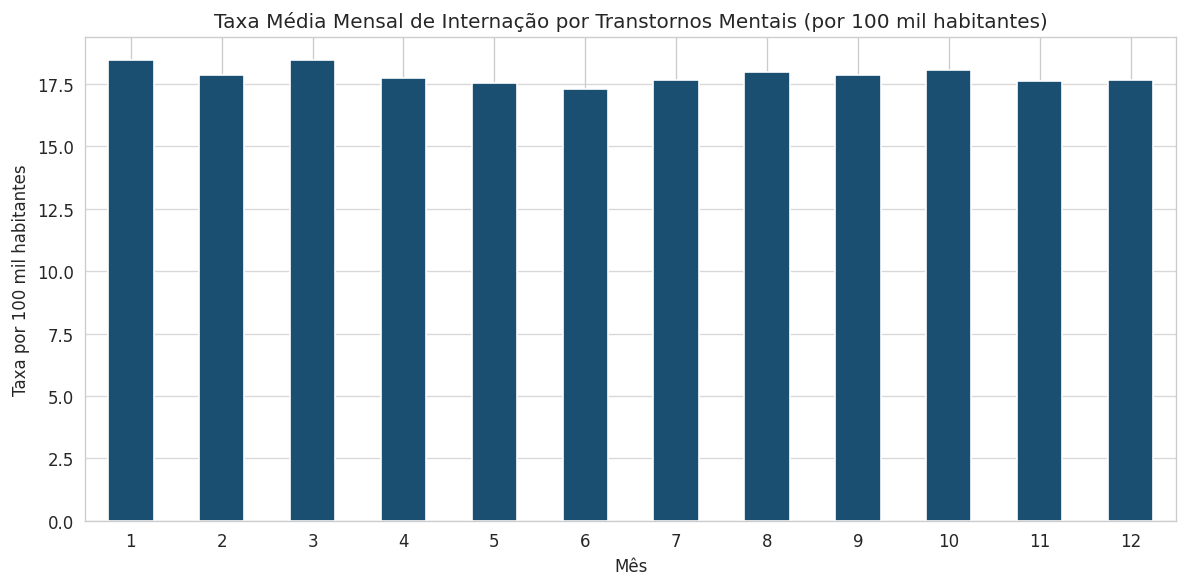

In [ ]:
mensal_media_taxa = df_taxa.groupby(df_taxa['data'].dt.month)['taxa_100k'].mean()

plt.figure(figsize=(10, 5))
mensal_media_taxa.plot(kind='bar', color=COLOR1)
plt.title('Taxa Média Mensal de Internação por Transtornos Mentais (por 100 mil habitantes)')
plt.xlabel('Mês')
plt.ylabel('Taxa por 100 mil habitantes')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## **5. Tabela 1: Características Gerais por Período**

In [ ]:
# Decodificações necessárias para a Tabela 1
df_tratado['SEXO_DESC']    = df_tratado['SEXO'].map({'1': 'Masculino', '3': 'Feminino'})
df_tratado['RACA_DESC']    = df_tratado['RACA_COR'].map({
    '01': 'Branca', '02': 'Parda', '03': 'Preta',
    '04': 'Amarela', '05': 'Indígena', '99': 'Ignorado'
})
df_tratado['CAR_INT_DESC']  = df_tratado['CAR_INT'].map({'01': 'Eletivo', '02': 'Urgência'})
df_tratado['evasao']        = df_tratado['MUNIC_RES'] != df_tratado['MUNIC_MOV']

In [ ]:
def tabela1(grupo):
    return pd.Series({
        'N internações'             : len(grupo),
        'Média mensal'              : round(len(grupo) / grupo['ANO_CMPT'].nunique() / 12, 0),
        'Idade — média (dp)'        : f'{grupo["IDADE"].mean():.1f} ({grupo["IDADE"].std():.1f})',
        'Idade — mediana'           : grupo['IDADE'].median(),
        '% Feminino'               : f'{(grupo["SEXO_DESC"] == "Feminino").mean()*100:.1f}%',
        '% Masculino'              : f'{(grupo["SEXO_DESC"] == "Masculino").mean()*100:.1f}%',
        '% Branca'                 : f'{(grupo["RACA_DESC"] == "Branca").mean()*100:.1f}%',
        '% Parda'                  : f'{(grupo["RACA_DESC"] == "Parda").mean()*100:.1f}%',
        '% Preta'                  : f'{(grupo["RACA_DESC"] == "Preta").mean()*100:.1f}%',
        '% Ignorado (raça)'        : f'{(grupo["RACA_DESC"] == "Ignorado").mean()*100:.1f}%',
        'Dias perm. — média (dp)'  : f'{grupo["DIAS_PERM"].mean():.1f} ({grupo["DIAS_PERM"].std():.1f})',
        'Dias perm. — mediana'     : grupo['DIAS_PERM'].median(),
        '% Urgência'               : f'{(grupo["CAR_INT_DESC"] == "Urgência").mean()*100:.1f}%',
        '% Óbito'                  : f'{grupo["MORTE"].astype(int).mean()*100:.2f}%',
        '% Evasão municipal'       : f'{grupo["evasao"].mean()*100:.1f}%',
    })

tabela_1 = df_tratado.groupby('periodo', observed=True).apply(tabela1).T
tabela_1['Total'] = df_tratado.pipe(tabela1)

tabela_1

/tmp/ipykernel_2187/1831525786.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabela_1 = df_tratado.groupby('periodo', observed=True).apply(tabela1).T


periodo,Pre-Pandemia,Pandemia,Pos-Pandemia,Total
N internações,572775,176312,330583,1079670
Média mensal,7955.0,4898.0,6887.0,8179.0
Idade — média (dp),44.5 (16.3),42.5 (15.9),40.7 (15.0),43.0 (15.9)
Idade — mediana,44.0,42.0,40.0,42.0
% Feminino,37.6%,38.2%,39.1%,38.1%
% Masculino,62.4%,61.8%,60.9%,61.9%
% Branca,54.1%,52.7%,55.0%,54.1%
% Parda,8.7%,9.1%,9.2%,8.9%
% Preta,21.9%,26.2%,34.0%,26.3%
% Ignorado (raça),14.8%,11.5%,1.2%,10.1%


In [ ]:
# Exportar Tabela 1 para CSV
tabela_1.to_csv('/content/drive/MyDrive/Tabelas/tabela1_panorama.csv', sep=';', encoding='utf-8-sig')
print('Tabela 1 exportada com sucesso.')

Tabela 1 exportada com sucesso.
